<a href="https://colab.research.google.com/github/AbShashwat/BLIP-Vision-Assistant/blob/main/blip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q transformers timm accelerate sentencepiece


In [3]:
from transformers import BlipProcessor, BlipForQuestionAnswering
from PIL import Image
from google.colab import files
import torch

In [4]:
# 3. Load Model and Processor
print("Loading BLIP VQA Model...")

processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-vqa-base"
)

model = BlipForQuestionAnswering.from_pretrained(
    "Salesforce/blip-vqa-base"
)

Loading BLIP VQA Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("Model loaded successfully on", device)

Model loaded successfully on cpu


In [6]:
print("\nUpload an image:")
uploaded = files.upload()


Upload an image:


Saving 22679076_bdb4c24401_m.jpg to 22679076_bdb4c24401_m.jpg


In [7]:
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

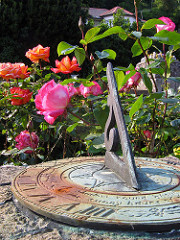

In [8]:
display(image)

In [9]:
print("\nImage uploaded successfully.")
print("You can now ask multiple questions about the image.")
print("Type 'exit', 'quit', or 'no' to stop.\n")


Image uploaded successfully.
You can now ask multiple questions about the image.
Type 'exit', 'quit', or 'no' to stop.



In [10]:
while True:

    question = input("Enter your question: ")

    if question.lower() in ["exit", "quit", "no"]:
        print("\nSession Ended. Thank you!")
        break

    inputs = processor(
        image,
        question,
        return_tensors="pt"
    ).to(device)

    outputs = model.generate(**inputs)

    answer = processor.decode(
        outputs[0],
        skip_special_tokens=True
    )

    print("\nAnswer :", answer)

    print("\nDo you have any other question?")
    print("-" * 50)

Enter your question: which flower is this?


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1612: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(



Answer : rose

Do you have any other question?
--------------------------------------------------
Enter your question: colour of the flower

Answer : pink

Do you have any other question?
--------------------------------------------------
Enter your question: exit

Session Ended. Thank you!
